# UDpipe2 process

Specific environment used -> Python (KreyolID) (see _udpipe_requirements.txt_) 

In this notebook, you will find:
1. Sentencisation/Tokenization/POS-tagging, output one CoNLL-U file per language
2. Filtering: remove sent. of fewer than 3 tokens
3. Model taggings comparison and Statistics

**_UPDATE: The part 1 of this notebook was finally not used because of the GPU needed to run UDpipe, the documents were then converged by languages and tokenized/tagged directly on the LINDAT REST SERVER website https://lindat.mff.cuni.cz/services/udpipe/_**

### 1. UDpipe2 process

Utilisation de UDpipe2 -> https://ufal.mff.cuni.cz/udpipe | https://lindat.mff.cuni.cz/services/udpipe/api-reference.php | https://github.com/ufal/udpipe/blob/udpipe-2/udpipe2_eval.py # ufal.udpipe: https://pypi.org/project/ufal.udpipe/

CoNNL-U -> https://universaldependencies.org/format.html | conllu: https://pypi.org/project/conllu/

https://lindat.mff.cuni.cz/services/udpipe/

In [3]:
# Libraries and models
from ufal.udpipe import Model, Pipeline, ProcessingError
import conllu
import os
import json

# Load model 
model_path = r"Desktop/STAGE/Thèse/3-UDpipe2_pipeline/ht_adolphe-ud-2.17-251125.udpipe"

model = Model.load(model_path)
if not model:
    raise FileNotFoundError(f"Model not found at: {model_path}")

pipeline = Pipeline(model, "tokenize", Pipeline.DEFAULT, Pipeline.NONE, "conllu") # tokenize and tag only, parsing disabled

ModuleNotFoundError: No module named 'udpipe'

In [ ]:
# lexicon dictionary (aide au dico : RDV page UDpipe modèles pour hai + lexique de R. Dent + les wordclouds)

CREOLE_LEXICON = {
    "ka": "AUX", "k'a": "AUX", "té": "AUX",
    "ké": "AUX", "kay": "AUX",
    "pa": "ADV", "pan": "PART", "ap":"AUX",
    "mwen": "PRON", 
    "ou": "PRON", "li": "PRON", "w": "PRON",
    "nou": "PRON", "zot": "PRON", "yo": "PRON",
    "yé": "AUX",
    "la": "DET", "a": "DET",
    "pou": "SCONJ",
    "moin": "PRON"
}
# pas de "sé" car peut être AUX ou PART(?) pour pluriel

In [ ]:
# Core functions

def open_file(file_path: str) -> str:
    """Open UTF-8 text file and return its content as one string."""
    with open(file_path, "r", encoding="utf-8", errors='ignore') as f:
        content = f.read()
    return content

def annotate(text: str) -> str:
    """Tokenize and tag raw text with UDPipe. Returns CoNLL-U string."""
    error = ProcessingError()
    result = pipeline.process(text, error)
    if error.occurred():
        raise RuntimeError(error.message)
    return result


def apply_lexicon(conllu_string: str, lexicon: dict) -> str:
    """Override UDPipe POS tags for known Creole function words."""
    sentences = conllu.parse(conllu_string)
    for sentence in sentences:
        for token in sentence:
            if not isinstance(token["id"], int):
                continue
            corrected = lexicon.get(token["form"].lower())
            if corrected and token["upos"] != corrected:
                token["upos"] = corrected
    return "".join(s.serialize() for s in sentences)


def add_metadata_bulk(conllu_string: str,
                      variety: str,
                      island: str,
                      source: str) -> tuple:
    """
    Add metadata to all sentences in a merged file.
    Returns: annotated CoNLL-U string, number of sentences processed.
    """
    sentences = conllu.parse(conllu_string)
    for i, sentence in enumerate(sentences):
        global_sent_id = sent_offset + i
        sentence.metadata["sent_id"] = f"{variety}_{global_sent_id:06d}"
        sentence.metadata["variety"] = variety
        sentence.metadata["island"]  = island
        sentence.metadata["source"]  = source
    return "".join(s.serialize() for s in sentences), len(sentences)


def process_document(text, variety, island):
    """Full pipeline."""
    raw = annotate(text)
    #corrected = apply_lexicon(raw, CREOLE_LEXICON)
    final = add_metadata(raw, variety) # corrected
    return final

In [ ]:
# Test application on a single sentence

test_sentence = "Mwen pa ka manjé vyann."

result = process_document(
    text=test_sentence,
    variety="mqc",
    island="martinique"
)

print(result)
# peut-être que je peux juste copier ça x4 et remplacer la test-sentence par les fichiers
# voir exactement ce que font les fonctions (output conllu files ??)
# remplir le dico avec d'autres unités lex.

In [ ]:
# Import corpora UTF-8 text files

text_gdl = open_file(r"gdl_guadeloupe_corpus.txt")
text_gfr = open_file(r"gfr_guyane_corpus.txt")
text_hcr = open_file(r"hcr_haiti_corpus.txt")
text_mqc = open_file(r"mqc_martinique_corpus.txt")

#à moins cela soit plus rapide -> text = open("gdl_guadeloupe_corpus.txt").read()

In [ ]:
result = process_document(
    text=text_gdl,
    variety="gdl",
    island="guadeloupe",
    source="fnw_glotcc"
)

print(result)
# les fichiers devraient juste s'appeler "annotated_gdl_corpus" et c'est tout

In [ ]:
# Register annotated corpora into json files

LANGUAGE_FILES = {
    "./corpus/raw/acf_martinique.txt": {
        "variety": "acf",
        "island":  "martinique",
        "source":  "mixed_web"
    },
    "./corpus/raw/gcf_guadeloupe.txt": {
        "variety": "gcf",
        "island":  "guadeloupe",
        "source":  "mixed_web"
    },
    "./corpus/raw/mfe_mauritius.txt": {
        "variety": "mfe",
        "island":  "mauritius",
        "source":  "mixed_web"
    },
    "./corpus/raw/rcf_reunion.txt": {
        "variety": "rcf",
        "island":  "reunion",
        "source":  "mixed_web"
    },
}

OUTPUT_DIR = "./corpus/conllu/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
for filepath, meta in LANGUAGE_FILES.items():
    variety = meta["variety"]
    print(f"\nProcessing {variety} — {filepath}")

    with open(filepath, encoding="utf-8") as f:
        raw_text = f.read()

    # Step 1: UDPipe annotation (entire file at once — fine at this scale)
    raw_conllu = annotate(raw_text)

    # Step 2: Lexicon correction
    corrected = apply_lexicon(raw_conllu, CREOLE_LEXICON)

    # Step 3: Metadata injection
    final, n_sents = add_metadata_bulk(
        corrected,
        variety=meta["variety"],
        island=meta["island"],
        source=meta["source"],
        sent_offset=0  # always starts at 0 since each file is independent
    )

    output_path = os.path.join(OUTPUT_DIR, f"{variety}.conllu")
    with open(output_path, "w", encoding="utf-8") as out_f:
        out_f.write(final)

    print(f"  ✓ {n_sents} sentences → {output_path}")

In [ ]:
# Verify each output file: count sentences and show first 3
for filepath, meta in LANGUAGE_FILES.items():
    variety = meta["variety"]
    out_path = os.path.join(OUTPUT_DIR, f"{variety}.conllu")

    with open(out_path, encoding="utf-8") as f:
        content = f.read()

    sentences = conllu.parse(content)
    print(f"\n{variety}: {len(sentences)} sentences")
    print(f"  First sentence: {sentences[0].metadata.get('text', '[no text]')}")
    print(f"  Tokens: {[t['form'] for t in sentences[0] if isinstance(t['id'], int)]}")
    print(f"  POS:    {[t['upos'] for t in sentences[0] if isinstance(t['id'], int)]}")

### 2. Tokenization and POS-tagging Comparison between haitian-adolphe and french-gsd models

#### 2.1 Installations

In [3]:
conda install -c pyconll pyconll


Note: you may need to restart the kernel to use updated packages.Retrieving notices: ...working... done
Solving environment: ...working... done

## Package Plan ##

  environment location: C:\Users\Elise\anaconda3\envs\KreyolID

  added / updated specs:
    - pyconll


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    pyconll-3.3.1              |             py_0          97 KB  pyconll
    ------------------------------------------------------------
                                           Total:          97 KB

The following NEW packages will be INSTALLED:

  pyconll            pyconll/noarch::pyconll-3.3.1-py_0 




pyconll-3.3.1        | 97 KB     |            |   0% 
pyconll-3.3.1        | 97 KB     | ########## | 100% 
pyconll-3.3.1        | 97 KB     | ########## | 100% 
                                                     


Preparing transaction: ...working... done
Verifying tr

Error while loading conda entry point: anaconda-cloud-auth (cannot import name 'ChannelAuthBase' from 'conda.plugins.types' (C:\Users\Elise\anaconda3\Lib\site-packages\conda\plugins\types.py))
Error while loading conda entry point: anaconda-cloud-auth (cannot import name 'ChannelAuthBase' from 'conda.plugins.types' (C:\Users\Elise\anaconda3\Lib\site-packages\conda\plugins\types.py))


==> WARNING: A newer version of conda exists. <==
  current version: 23.7.4
  latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.5.3




In [1]:
import pyconll
print(pyconll.__version__)
print(pyconll.__file__)

3.3.1
C:\Users\Elise\anaconda3\Lib\site-packages\pyconll\__init__.py


In [5]:
!pip install --upgrade pyconll

In [16]:
!pip show pyconll

Name: pyconll
Version: 3.3.1
Summary: Read and manipulate CoNLL files
Home-page: https://github.com/pyconll/pyconll
Author: Matias Grioni
Author-email: matgrioni@gmail.com
License: MIT
Location: C:\Users\Elise\anaconda3\Lib\site-packages
Requires: 
Required-by: 


In [3]:
from collections import Counter

#### 2.2 Loading and filtering conllu files

In [5]:
# Load the conllu files
# The method 'load_from_file' uses the file path and returns an iterator over the sentences.
gdl_ht_sent = pyconll.load_from_file(r'./annot_gdl_ht-adolphe_1341s.conllu')  
gdl_fr_sent = pyconll.load_from_file(r'./annot_gdl_french-gsd_1255s.conllu')
mqc_ht_sent = pyconll.load_from_file(r'./annot_mqc_ht-adolphe_1049s.conllu')
mqc_fr_sent = pyconll.load_from_file(r'./annot_mqc_french-gsd_981s.conllu')
gfr_ht_sent = pyconll.load_from_file(r'./annot_gfr_ht-adolphe_553s.conllu')
gfr_fr_sent = pyconll.load_from_file(r'./annot_gfr_french-gsd_514s.conllu')
hcr_ht_sent = pyconll.load_from_file(r'./annot_hcr_ht-adolphe_1528s.conllu')
hcr_fr_sent = pyconll.load_from_file(r'./annot_hcr_french-gsd_1428s.conllu')

In [7]:
print(type(gdl_ht_sent))

<class 'pyconll.unit.conll.Conll'>


In [13]:
print(f'Number of sentences for ht model: gdl-{len(gdl_ht_sent)}, mqc-{len(mqc_ht_sent)}, gfr-{len(gfr_ht_sent)}, hcr-{len(hcr_ht_sent)}')
print(f'Number of sentences for fr model: gdl-{len(gdl_fr_sent)}, mqc-{len(mqc_fr_sent)}, gfr-{len(gfr_fr_sent)}, hcr-{len(hcr_fr_sent)}')

Number of sentences for ht model: gdl-1341, mqc-1049, gfr-553, hcr-1528
Number of sentences for fr model: gdl-1255, mqc-981, gfr-514, hcr-1428


In [15]:
# Filtering out sentences with fewer than 3 tokens
# https://pypi.org/project/conllu/

def filter_3t_sent(conllu_content):
    """Filters out sentences with fewer than 3 tokens in a conllu file (hereby called 'conllu_content').
    Input: conllu file content.
    Outputs: a string count of what is removed, a list of the removed sentences, and the filtered conllu file."""
    kept, removed = [], []
    for sentence in conllu_content:
        if len(sentence) >= 3:
            kept.append(sentence)
        else:
            removed.append(sentence)
    return removed, kept

# (choix de ne pas éliminer les réduplications, but est de voir les constructions les plus fréquentes...)

In [17]:
removed_gdl_ht, gdl_ht_sent_f = filter_3t_sent(gdl_ht_sent)
removed_mqc_ht, mqc_ht_sent_f = filter_3t_sent(mqc_ht_sent)
removed_gfr_ht, gfr_ht_sent_f = filter_3t_sent(gfr_ht_sent)
removed_hcr_ht, hcr_ht_sent_f = filter_3t_sent(hcr_ht_sent)

In [19]:
print(f"Filtering for gdl_ht: {len(removed_gdl_ht)} of sentences removed, {(len(gdl_ht_sent_f)/len(gdl_ht_sent))*100}% of sentences kept.")
print(f"Filtering for mqc_ht: {len(removed_mqc_ht)} of sentences removed, {(len(mqc_ht_sent_f)/len(mqc_ht_sent))*100}% of sentences kept.")
print(f"Filtering for gfr_ht: {len(removed_gfr_ht)} of sentences removed, {(len(gfr_ht_sent_f)/len(gfr_ht_sent))*100}% of sentences kept.")
print(f"Filtering for hcr_ht: {len(removed_hcr_ht)} of sentences removed, {(len(hcr_ht_sent_f)/len(hcr_ht_sent))*100}% of sentences kept.")

Filtering for gdl_ht: 54 of sentences removed, 95.9731543624161% of sentences kept.
Filtering for mqc_ht: 21 of sentences removed, 97.99809342230697% of sentences kept.
Filtering for gfr_ht: 19 of sentences removed, 96.56419529837251% of sentences kept.
Filtering for hcr_ht: 41 of sentences removed, 97.31675392670157% of sentences kept.


In [39]:
# Checking that only raw tokens have been considered (no multiword tokens '-' or empty nodes '.')
# since they do not carry POS annotations themselves
for sentence in gfr_ht_sent:
    if any('-' in tok.id or '.' in tok.id for tok in sentence):
        print(sentence.id, len(sentence), [t.id for t in sentence])
        break

In [21]:
removed_gdl_fr, gdl_fr_sent_f = filter_3t_sent(gdl_fr_sent)
removed_mqc_fr, mqc_fr_sent_f = filter_3t_sent(mqc_fr_sent)
removed_gfr_fr, gfr_fr_sent_f = filter_3t_sent(gfr_fr_sent)
removed_hcr_fr, hcr_fr_sent_f = filter_3t_sent(hcr_fr_sent)
print(f"Filtering for gdl_fr: {len(removed_gdl_fr)} of sentences removed, {(len(gdl_fr_sent_f)/len(gdl_fr_sent))*100}% of sentences kept.")
print(f"Filtering for mqc_fr: {len(removed_mqc_fr)} of sentences removed, {(len(mqc_fr_sent_f)/len(mqc_fr_sent))*100}% of sentences kept.")
print(f"Filtering for gfr_fr: {len(removed_gfr_fr)} of sentences removed, {(len(gfr_fr_sent_f)/len(gfr_fr_sent))*100}% of sentences kept.")
print(f"Filtering for hcr_fr: {len(removed_hcr_fr)} of sentences removed, {(len(hcr_fr_sent_f)/len(hcr_fr_sent))*100}% of sentences kept.")

Filtering for gdl_fr: 15 of sentences removed, 98.80478087649402% of sentences kept.
Filtering for mqc_fr: 11 of sentences removed, 98.87869520897044% of sentences kept.
Filtering for gfr_fr: 4 of sentences removed, 99.22178988326849% of sentences kept.
Filtering for hcr_fr: 15 of sentences removed, 98.94957983193278% of sentences kept.


In [23]:
print(f'Total number of sentences for ht model: gdl-{len(gdl_ht_sent_f)}, mcq-{len(mqc_ht_sent_f)}, gfr-{len(gfr_ht_sent_f)}, hcr-{len(hcr_ht_sent_f)} | TOTAL-{(len(gdl_ht_sent_f)+len(mqc_ht_sent_f)+len(gfr_ht_sent_f)+len(hcr_ht_sent_f))}')
print(f'Total number of sentences for fr model: gdl-{len(gdl_fr_sent_f)}, mcq-{len(mqc_fr_sent_f)}, gfr-{len(gfr_fr_sent_f)}, hcr-{len(hcr_fr_sent_f)} | TOTAL-{(len(gdl_fr_sent_f)+len(mqc_fr_sent_f)+len(gfr_fr_sent_f)+len(hcr_fr_sent_f))}')

Total number of sentences for ht model: gdl-1287, mcq-1028, gfr-534, hcr-1487 | TOTAL-4336
Total number of sentences for fr model: gdl-1240, mcq-970, gfr-510, hcr-1413 | TOTAL-4133


#### 2.3 Count tokens of the respective files

In [ ]:
def count_token(conllu_content):
    """Count the token in a conllu file.
    Input: conllu file content.
    Outputs: Number of raw tokens, Number of multiword tokens, and Number of empty tokens."""
    nb_tokens = 0
    nb_multiword = 0
    nb_empty = 0
    
    for sentence in conllu_content:
        for token in sentence:
            if '-' in token.id:
                nb_multiword += 1
            elif '.' in token.id:
                nb_empty += 1
            else:
                nb_tokens += 1
    return nb_tokens, nb_multiword, nb_empty

#ht model
gdl_ht_nb_tokens, gdl_ht_nb_mtw, gdl_ht_nb_empty = count_token(gdl_ht_sent_f)
mqc_ht_nb_tokens, mqc_ht_nb_mtw, mqc_ht_nb_empty = count_token(mqc_ht_sent_f)
gfr_ht_nb_tokens, gfr_ht_nb_mtw, gfr_ht_nb_empty = count_token(gfr_ht_sent_f)
hcr_ht_nb_tokens, hcr_ht_nb_mtw, hcr_ht_nb_empty = count_token(hcr_ht_sent_f)
#fr model
gdl_fr_nb_tokens, gdl_fr_nb_mtw, gdl_fr_nb_empty = count_token(gdl_fr_sent_f)
mqc_fr_nb_tokens, mqc_fr_nb_mtw, mqc_fr_nb_empty = count_token(mqc_fr_sent_f)
gfr_fr_nb_tokens, gfr_fr_nb_mtw, gfr_fr_nb_empty = count_token(gfr_fr_sent_f)
hcr_fr_nb_tokens, hcr_fr_nb_mtw, hcr_fr_nb_empty = count_token(hcr_fr_sent_f)

In [111]:
#ht model
print(f"For gdl with ht model -> Raw Tokens: {gdl_ht_nb_tokens}, Multiword tokens: {gdl_ht_nb_mtw}, Empty nodes: {gdl_ht_nb_empty}")
print(f"For mqc with ht model -> Raw Tokens: {mqc_ht_nb_tokens}, Multiword tokens: {mqc_ht_nb_mtw}, Empty nodes: {mqc_ht_nb_empty}")
print(f"For gfr with ht model -> Raw Tokens: {gfr_ht_nb_tokens}, Multiword tokens: {gfr_ht_nb_mtw}, Empty nodes: {gfr_ht_nb_empty}")
print(f"For hcr with ht model -> Raw Tokens: {hcr_ht_nb_tokens}, Multiword tokens: {hcr_ht_nb_mtw}, Empty nodes: {hcr_ht_nb_empty}\n")
#fr model
print(f"For gdl with fr model -> Raw Tokens: {gdl_fr_nb_tokens}, Multiword tokens: {gdl_fr_nb_mtw}, Empty nodes: {gdl_fr_nb_empty}")
print(f"For mqc with fr model -> Raw Tokens: {mqc_fr_nb_tokens}, Multiword tokens: {mqc_fr_nb_mtw}, Empty nodes: {mqc_fr_nb_empty}")
print(f"For gfr with fr model -> Raw Tokens: {gfr_fr_nb_tokens}, Multiword tokens: {gfr_fr_nb_mtw}, Empty nodes: {gfr_fr_nb_empty}")
print(f"For hcr with fr model -> Raw Tokens: {hcr_fr_nb_tokens}, Multiword tokens: {hcr_fr_nb_mtw}, Empty nodes: {hcr_fr_nb_empty}")

For gdl with ht model -> Raw Tokens: 23786, Multiword tokens: 0, Empty nodes: 0
For mqc with ht model -> Raw Tokens: 19741, Multiword tokens: 0, Empty nodes: 0
For gfr with ht model -> Raw Tokens: 9907, Multiword tokens: 0, Empty nodes: 0
For hcr with ht model -> Raw Tokens: 33865, Multiword tokens: 0, Empty nodes: 0

For gdl with fr model -> Raw Tokens: 23722, Multiword tokens: 8, Empty nodes: 0
For mqc with fr model -> Raw Tokens: 19559, Multiword tokens: 6, Empty nodes: 0
For gfr with fr model -> Raw Tokens: 9958, Multiword tokens: 1, Empty nodes: 0
For hcr with fr model -> Raw Tokens: 33719, Multiword tokens: 6, Empty nodes: 0


#### 2.3 Registering both removed and filtered conllu files

In [99]:
# Register discarded sentences (in adding mode)
def download_removed_sent(removed_sent, lang, model):
    """Downloads as one single conllu file containing all removed sentences. Takes the removed sentences list as input."""
    with open('removed_short_sentences.conllu', 'a', encoding='utf-8') as f:
        f.write(f'#REMOVED SENTENCES FOR {lang} LANGUAGE WITH {model} MODEL\n\n')
        for sentence in removed_sent:
            f.write(sentence.conll())
        f.write(f"\n\n{'-'*50}\n\n")

In [101]:
# Applying the 'download_removed_sent' function on ht model files
download_removed_sent(removed_gdl_ht, 'gdl', 'ht-adolphe-2.17-251125')
download_removed_sent(removed_mqc_ht, 'mqc', 'ht-adolphe-2.17-251125')
download_removed_sent(removed_gfr_ht, 'gfr', 'ht-adolphe-2.17-251125')
download_removed_sent(removed_hcr_ht, 'hcr', 'ht-adolphe-2.17-251125')
# Applying the 'download_removed_sent' function on fr model files
download_removed_sent(removed_gdl_ht, 'gdl', 'fr-gsd-2.17-251125')
download_removed_sent(removed_mqc_ht, 'mqc', 'fr-gsd-2.17-251125')
download_removed_sent(removed_gfr_ht, 'gfr', 'fr-gsd-2.17-251125')
download_removed_sent(removed_hcr_ht, 'hcr', 'fr-gsd-2.17-251125')

In [25]:
# Register filtered sentences (in writing mode)
def download_filtered_sent(file_name, removed_sent, lang, model):
    """Downloads filtered sentences in one conllu file per language and model. Takes as input the filtered sentences list."""
    with open(file_name, 'w', encoding='utf-8') as f:
        f.write(f'#FILTERED SENTENCES FOR {lang} LANGUAGE WITH {model} MODEL\n\n')
        for sentence in removed_sent:
            f.write(f'{sentence.conll()}\n\n')

In [27]:
# Applying the 'download_filtered_sent' function on ht model files
download_filtered_sent('filtered_gdl_ht-adolphe_1287s.conllu', gdl_ht_sent_f, 'gdl', 'ht-adolphe-2.17-251125')
download_filtered_sent('filtered_mqc_ht-adolphe_1028s.conllu', mqc_ht_sent_f, 'mqc', 'ht-adolphe-2.17-251125')
download_filtered_sent('filtered_gfr_ht-adolphe_534s.conllu', gfr_ht_sent_f, 'gfr', 'ht-adolphe-2.17-251125')
download_filtered_sent('filtered_hcr_ht-adolphe_1487s.conllu', hcr_ht_sent_f, 'hcr', 'ht-adolphe-2.17-251125')
# Applying the 'download_filtered_sent' function on fr model files
download_filtered_sent('filtered_gdl_fr-gsd_1240s.conllu', gdl_fr_sent_f, 'gdl', 'fr-gsd-2.17-251125')
download_filtered_sent('filtered_mqc_fr-gsd_970s.conllu', mqc_fr_sent_f, 'mqc', 'fr-gsd-2.17-251125')
download_filtered_sent('filtered_gfr_fr-gsd_510s.conllu', gfr_fr_sent_f, 'gfr', 'fr-gsd-2.17-251125')
download_filtered_sent('filtered_hcr_fr-gsd_1413s.conllu', hcr_fr_sent_f, 'hcr', 'fr-gsd-2.17-251125')

#### 2.4 Statistics and Observations

Number of sentences automatically calculated during the UDpipe2 process:

|/| ht_adolphe_model | french_gsd_model | Difference between the two |
|-|------------------|------------------|----------------------------|
| **gdl/gua** | 1341 | 1255 | 86 |
| **gfr/guy** | 553 | 514 | 39 |
| **hcr/hai** | 1528 | 1428 | 100 |
| **mqc/mar** | 1049 | 981 | 68 |
| **TOTAL** | 4471 | 4178 | 293 |


Mean of the difference: 73,25 \
Total number of sentences: 4471 (ht), 4178 (fr) \
Difference between the total number of sentences: 293 (Percentage of evolution between those two values: -6,55%) \
Formula = ( (Nombre final - Nombre initial) ÷ |Nombre initial| ) x 100

Proportion of each creole in the corpus (based on sentences + doesn't change much across the models): 

|/| ht_adolphe_model | french_gsd_model |
|-|------------------|------------------|
| **gdl/gua** | 29,99% | 30,04% |
| **gfr/guy** | 12,37% | 12,30% |
| **hcr/hai** | 34,18% | 34,18% |
| **mqc/mar** | 23,46% | 23,48% |

Formula = (Nombre ÷ Total) x 100 

(faire le même tableau pour les deux corpus sources pour voir la part de corpus pour chacun)

Number of sentences after filtering:

|/| ht_adolphe_model | french_gsd_model | Difference of sentences number between the models | 
|-|------------------|------------------|--------------------------------------|
| **gdl/gua** | 1287 | 1240 | 47 |
| **gfr/guy** | 534 | 510 | 24 |
| **hcr/hai** | 1487 | 1413 | 74 |
| **mqc/mar** | 1028 | 970 | 58 |
| **TOTAL**   | 4 336 | 4 133 | 203 | 

Number of sentences removed:
|/| ht_adolphe_model | french_gsd_model | 
|-|------------------|------------------|
| **gdl/gua** | 54 | 15 |
| **gfr/guy** | 19 | 4 |
| **hcr/hai** | 41 | 15 |
| **mqc/mar** | 21 | 11 |
| **TOTAL**   | 135 | 45 |

Percentage of sentences removed:
|/| ht_adolphe_model | french_gsd_model | 
|-|------------------|------------------|
| **gdl/gua** | 4% | 1,2% |
| **gfr/guy** | 3,4% | 0,8% |
| **hcr/hai** | 2,6% | 1% |
| **mqc/mar** | 2% | 1,1% |
| **TOTAL**   | 12% | 4,1% |

Final number of (raw) tokens of each language in the corpus:
|/| ht_adolphe_model | french_gsd_model | Difference between the two models |
|-|------------------|------------------|-----------------------------------|
| **gdl/gua** | 23 786 | 23 722 | 64 |
| **gfr/guy** | 9 907 | 9 958 | -51 |
| **hcr/hai** | 33 865 | 33 719 | 146 |
| **mqc/mar** | 19 741 | 19 559 | 182 |
| **TOTAL**   | 87 299 | 86 958 | 341 |

Between the French and the Haitian models, the French one has found 341 fewer tokens than the Haitian one, as well as 203 fewer sentences (after filtering out sentences with fewer than 3 tokens).

Final proportion of each language in the corpus (based on tokens):
|/| ht_adolphe_model | french_gsd_model | 
|-|------------------|------------------|
| **gdl/gua** | 27,2% | 27,3% |
| **gfr/guy** | 11,3% | 11,5% |
| **hcr/hai** | 38,8% | 38,8% |
| **mqc/mar** | 22,6% | 22,5% |

gdl quasi 27%, hcr quasi 39%, mqc 23%, gfr 11% = 100%

_*all percentages in tables are rounded to the nearest tenth / one decimal place_

In [119]:
# Token ratio per language
def token_ratio(nb_tokens_ht, nb_tokens_fr, lang):
    ratio = nb_tokens_ht / nb_tokens_fr
    return f"{lang} token ratio (A/B): {ratio:.4f}"

gdl_ratio = token_ratio(gdl_ht_nb_tokens, gdl_fr_nb_tokens, 'gdl')
mqc_ratio = token_ratio(mqc_ht_nb_tokens, mqc_fr_nb_tokens, 'mqc')
gfr_ratio = token_ratio(gfr_ht_nb_tokens, gfr_fr_nb_tokens, 'gfr')
hcr_ratio = token_ratio(hcr_ht_nb_tokens, hcr_fr_nb_tokens, 'hcr')

print(f'{gdl_ratio}\n{mqc_ratio}\n{gfr_ratio}\n{hcr_ratio}')

gdl token ratio (A/B): 1.0027
mqc token ratio (A/B): 1.0093
gfr token ratio (A/B): 0.9949
hcr token ratio (A/B): 1.0043


**-> ALLER VOIR L'OUTIL EN LIGNE VU EN CLASSE POUR L'EVALUATION DE LA TOKENIZATION**

ratio ≈ 1.0 → the two models tokenize the corpus into roughly the same number of words overall. Doesn't mean they agree token-by-token, just that their overall granularity is similar. \
ratio > 1.0 → Model A produced more tokens than Model B on the same corpus. This usually means Model A over-segments relative to B — e.g. splitting more punctuation, contractions, or compounds into separate tokens, or possibly under-merging where B correctly fuses forms. \
ratio < 1.0 → Model A produced fewer tokens — it's merging more aggressively, or missing splits that B correctly identifies (e.g. not detecting a contraction B does).

What we can already observe from the statistics of the two models' performances on our corpora is:
- lower number of sentences
- lower number of tokens
- unknown words tagged X with fr model (a lot)
- foreign=yes appears with fr model
- multiword tokens appear with fr model
- after observation in the file, lemmas reports flexionable words (while there are not)

What about pos-tagging? -> alignement needed?

In [17]:
# starting with upos for comparability

def get_pos_tags(corpus, tagset='upos'):
    """Obtain all POS tags as a list from the content of a conllu file.
    Returns two objects: one flat list with all tags, one list of lists to catch tags per sentence."""
    #corpus = pyconll.load_from_file(file_path)
    all_tags = []       # flat list, corpus-wide
    per_sentence = []   # list of lists, one per sentence

    for sentence in corpus:
        sent_tags = []
        for token in sentence:
            if '-' in token.id or '.' in token.id:    # skipping multiword-token ranges and empty nodes
                continue
            tag = token.upos if tagset == 'upos' else token.xpos
            sent_tags.append(tag)
        per_sentence.append(sent_tags)
        all_tags.extend(sent_tags)

    return all_tags, per_sentence

# ht model
gdl_ht_all_tags, gdl_ht_tag_sents = get_pos_tags(gdl_ht_sent_f, tagset='upos')
mqc_ht_all_tags, mqc_ht_tag_sents = get_pos_tags(mqc_ht_sent_f, tagset='upos')
gfr_ht_all_tags, gfr_ht_tag_sents = get_pos_tags(gfr_ht_sent_f, tagset='upos')
hcr_ht_all_tags, hcr_ht_tag_sents = get_pos_tags(hcr_ht_sent_f, tagset='upos')
# fr model
gdl_fr_all_tags, gdl_fr_tag_sents = get_pos_tags(gdl_fr_sent_f, tagset='upos')
mqc_fr_all_tags, mqc_fr_tag_sents = get_pos_tags(mqc_fr_sent_f, tagset='upos')
gfr_fr_all_tags, gfr_fr_tag_sents = get_pos_tags(gfr_fr_sent_f, tagset='upos')
hcr_fr_all_tags, hcr_fr_tag_sents = get_pos_tags(hcr_fr_sent_f, tagset='upos')

In [19]:
print(hcr_fr_tag_sents[51])

['INTJ', 'DET', 'ADP', 'ADV', 'PRON', 'VERB', 'ADJ', 'ADP', 'PROPN', 'PUNCT']


In [21]:
# Concatenate lists by model (one list for ht, one list for fr)
ht_all_tags = gdl_ht_all_tags + mqc_ht_all_tags + gfr_ht_all_tags + hcr_ht_all_tags
fr_all_tags = gdl_fr_all_tags + mqc_fr_all_tags + gfr_fr_all_tags + hcr_fr_all_tags

print(fr_all_tags[10:30]) 

['VERB', 'AUX', 'ADP', 'NOUN', 'ADV', 'NOUN', 'ADJ', 'PUNCT', 'ADV', 'VERB', 'PRON', 'PUNCT', 'ADV', 'CCONJ', 'AUX', 'VERB', 'DET', 'NOUN', 'ADJ', 'AUX']


In [25]:
print(f'POS tags number for ht-adolphe model: {len(ht_all_tags)}\nPOS tags number for fr-gsd model: {len(fr_all_tags)}')

POS tags number for ht-adolphe model: 87299
POS tags number for fr-gsd model: 86958


In [27]:
ht_tag_sents = gdl_ht_tag_sents + mqc_ht_tag_sents + gfr_ht_tag_sents + hcr_ht_tag_sents
fr_tag_sents = gdl_fr_tag_sents + mqc_fr_tag_sents + gfr_fr_tag_sents + hcr_fr_tag_sents

print(fr_tag_sents[20:30]) 

[['PROPN', 'PROPN', 'VERB', 'PROPN', 'ADP', 'NOUN', 'ADJ', 'DET', 'NUM', 'NOUN', 'NUM', 'PUNCT'], ['PROPN', 'VERB', 'PROPN', 'ADP', 'NOUN', 'ADJ', 'VERB', 'PUNCT'], ['PROPN', 'PROPN', 'PUNCT'], ['PROPN', 'PROPN', 'PROPN', 'PRON', 'VERB', 'VERB', 'NOUN', 'PROPN', 'PUNCT'], ['X', 'PRON', 'X', 'PUNCT', 'X', 'X', 'X', 'PUNCT', 'PUNCT'], ['SCONJ', 'PRON', 'VERB', 'ADP', 'X', 'PROPN', 'PRON', 'DET', 'X', 'VERB', 'PRON', 'X', 'X', 'X', 'X', 'CCONJ', 'CCONJ', 'PRON', 'X', 'X', 'X', 'PUNCT', 'CCONJ', 'PRON', 'NOUN', 'ADP', 'X', 'PUNCT', 'VERB', 'ADV', 'VERB', 'ADP', 'NOUN', 'PUNCT'], ['NOUN', 'CCONJ', 'NOUN', 'NOUN', 'NOUN', 'ADV', 'PUNCT'], ['X', 'CCONJ', 'NOUN', 'CCONJ', 'X', 'CCONJ', 'VERB', 'NOUN', 'NOUN', 'DET', 'VERB', 'PRON', 'VERB', 'ADV', 'PUNCT', 'CCONJ', 'X', 'X', 'CCONJ', 'AUX', 'VERB', 'PRON', 'X', 'PRON', 'VERB', 'ADJ', 'PUNCT'], ['X', 'CCONJ', 'X', 'PUNCT', 'X', 'PUNCT', 'CCONJ', 'X', 'CCONJ', 'AUX', 'VERB', 'NOUN', 'PUNCT', 'CCONJ', 'X', 'X', 'CCONJ', 'VERB', 'SCONJ', 'X', 'PUNC

In [29]:
# check alignment of the two lists
mismatches = [(i, len(s_ht), len(s_fr)) for i, (s_ht, s_fr) in enumerate(zip(ht_tag_sents, fr_tag_sents)) if len(s_ht) != len(s_fr)]
print(f"{len(mismatches)} of {len(ht_tag_sents)} sentences have mismatched token counts")

3994 of 4336 sentences have mismatched token counts


-> 92% of the sentences have mismatched token counts

In [31]:
from collections import Counter

In [33]:
items_ht_all_tags = Counter(ht_all_tags)
print(items_ht_all_tags)

Counter({'NOUN': 19757, 'PUNCT': 11561, 'VERB': 11021, 'PRON': 10010, 'ADP': 5659, 'DET': 5544, 'AUX': 5165, 'ADV': 5097, 'ADJ': 4358, 'PROPN': 4101, 'CCONJ': 2340, 'SCONJ': 1567, 'NUM': 928, 'INTJ': 126, 'PART': 65})


In [35]:
items_fr_all_tags = Counter(fr_all_tags)
print(items_fr_all_tags)

Counter({'NOUN': 13403, 'VERB': 12819, 'PUNCT': 11133, 'PRON': 10531, 'X': 8148, 'PROPN': 6008, 'ADV': 5744, 'ADP': 4824, 'ADJ': 3682, 'DET': 3404, 'CCONJ': 2928, 'AUX': 1815, 'SCONJ': 1144, 'NUM': 915, 'INTJ': 250, 'SYM': 210})


In [37]:
print(f'The fr-gsd model has predicted {len(items_fr_all_tags)} different tags, while the ht-adolphe model has predicted {len(items_ht_all_tags)} different tags.')

The fr-gsd model has predicted 16 different tags, while the ht-adolphe model has predicted 15 different tags.


In [39]:
print(f'Tags used by ht model: {list(items_ht_all_tags.keys())}\nTags used by fr model: {list(items_fr_all_tags.keys())}')

Tags used by ht model: ['ADP', 'NOUN', 'ADJ', 'PUNCT', 'PROPN', 'AUX', 'VERB', 'PRON', 'SCONJ', 'DET', 'CCONJ', 'NUM', 'ADV', 'INTJ', 'PART']
Tags used by fr model: ['ADP', 'ADV', 'ADJ', 'PUNCT', 'PROPN', 'AUX', 'VERB', 'PRON', 'NOUN', 'CCONJ', 'DET', 'INTJ', 'X', 'SCONJ', 'NUM', 'SYM']


Observations:
- The Haitian model has predicted absolutely no X tag (meaning no words were unknown)
- The French model has predicted a significant amount of proper nouns (to check), much more than the Haitian one
- The French model has predicted many fewer nouns
- The French model has predicted much less auxillary verbs (which is significant)
- Haitian model use PART tag while French model does not
- The French model only has X and SYM tags

Also worth flagging (interpretation): \
Total tag counts are close (87,299 vs 86,958), so the models aren't wildly under/over-tokenizing overall — this fits with sentence-level segmentation differing internally while corpus size stays similar. \
Fr Model has 8,148 tokens tagged X, and ht Model has none. That's roughly 9% of ht Model's tokens dumped into a single catch-all tag. Combined with fr Model's noticeably lower AUX (1,815 vs 5,165) and DET (3,404 vs 5,544) counts, this looks less like "two taggers disagreeing at the margins" and more like fr Model is either :
1. using X as a fallback for a specific phenomenon ht Model tags more specifically (e.g. clitics, contractions, foreign/code-switched text, or unrecognized vocabulary) \
OR 
2. Something went wrong in that model's tagging pipeline for a subset of tokens.

(Option 1 preferred, since the model ran four times for each of the languages)\

In [41]:
# Investigation on X tags

def get_token_tagged_x(conllu_content):
    x_samples = []
    for sentence in conllu_content:
        for token in sentence:
            if token.upos == 'X':
                x_samples.append(token.form)
    
    return Counter(x_samples).most_common(30)

x_tags_gdl_fr = get_token_tagged_x(gdl_fr_sent_f)
x_tags_mqc_fr = get_token_tagged_x(mqc_fr_sent_f)
x_tags_gfr_fr = get_token_tagged_x(gfr_fr_sent_f)
x_tags_hcr_fr = get_token_tagged_x(hcr_fr_sent_f)

In [43]:
print(f'X tags in gdl:\n {x_tags_gdl_fr}\n---------------------\n')
print(f'X tags in mqc:\n {x_tags_mqc_fr}\n---------------------\n')
print(f'X tags in gfr:\n {x_tags_gfr_fr}\n---------------------\n')
print(f'X tags in hcr:\n {x_tags_hcr_fr}')

X tags in gdl:
 [('ka', 74), ('fè', 63), ('mwen', 60), ('a', 47), ('èvè', 45), ('sé', 35), ('a-y', 31), ('aw', 25), ('a-w', 24), ('an', 23), ('pa', 22), ('vwè', 20), ('adan', 18), ('pé', 17), ('sa', 16), ('ba', 15), ('ké', 15), ('épi', 14), ('tè', 14), ('oben', 13), ('ola', 13), ('glan', 13), ('pèp', 12), ('di', 12), ('lajan', 10), ('kè', 10), ('la', 10), ('baw', 10), ('nou', 10), ('pwan', 10)]
---------------------

X tags in mqc:
 [('mwen', 68), ('ka', 53), ('fè', 39), ('man', 30), ('pa', 29), ('ba', 26), ('a', 26), ('épi', 25), ('wè', 24), ('an', 22), ('té', 17), ('di', 14), ('anlè', 13), ('rhum', 13), ('adan', 12), ('sé', 12), ('davwè', 10), ('fok', 10), ('sa', 9), ('Man', 9), ('pran', 8), ('dan', 7), ('éti', 7), ('anlo', 7), ('kwè', 7), ('pli', 7), ('sav', 7), ('nou', 7), ('ganm', 7), ('dé', 6)]
---------------------

X tags in gfr:
 [('annan', 39), ('di', 37), ('ka', 21), ('-yan', 15), ('a', 13), ('oben', 13), ('fè', 11), ('ké', 11), ('Creative', 11), ('Attribution-pataj', 11), (

-> The tokens tagged as X by the Fr model are central words of creole languages.

In [45]:
# POS tags alignment (by character overlap)

def token_spans(sentence):
    """Reconstruct (start, end, tag) character spans for each token,
    using SpaceAfter=No to know whether tokens are separated by a space."""
    spans = []
    pos = 0
    for token in sentence:
        if '-' in token.id or '.' in token.id:
            continue  # skip MWT ranges and empty nodes
        start = pos
        end = pos + len(token.form)
        spans.append((start, end, token.upos))
        pos = end
        if token.misc.get('SpaceAfter') != {'No'}:
            pos += 1  # account for the space, if there was one
    return spans

def align_and_confuse(corpus_ht, corpus_fr):

    pairs = []
    skipped_sentences = 0

    for sent_ht, sent_fr in zip(corpus_ht, corpus_fr):
        if sent_ht.text != sent_fr.text:
            skipped_sentences += 1
            continue  # underlying text differs -- can't align safely

        spans_ht = token_spans(sent_ht)
        spans_fr = token_spans(sent_fr)

        for start_ht, end_ht, tag_ht in spans_ht:
            # find the fr model token with the most character overlap
            best_tag, best_overlap = None, 0
            for start_fr, end_fr, tag_fr in spans_fr:
                overlap = max(0, min(end_ht, end_fr) - max(start_ht, start_fr))
                if overlap > best_overlap:
                    best_overlap, best_tag = overlap, tag_fr
            if best_tag is not None:
                pairs.append((tag_ht, best_tag))

    print(f"Skipped {skipped_sentences} sentences (underlying text mismatch)")
    print(f"Aligned {len(pairs)} token pairs")
    return pairs

gdl_pairs = align_and_confuse(gdl_ht_sent_f, gdl_fr_sent_f)
mqc_pairs = align_and_confuse(mqc_ht_sent_f, mqc_fr_sent_f)
gfr_pairs = align_and_confuse(gfr_ht_sent_f, gfr_fr_sent_f)
hcr_pairs = align_and_confuse(hcr_ht_sent_f, hcr_fr_sent_f)

# ht model
aligned_gdl_tags_ht = [p[0] for p in gdl_pairs]
aligned_mqc_tags_ht = [p[0] for p in mqc_pairs]
aligned_gfr_tags_ht = [p[0] for p in gfr_pairs]
aligned_hcr_tags_ht = [p[0] for p in hcr_pairs]
# fr model
aligned_gdl_tags_fr = [p[1] for p in gdl_pairs]
aligned_mqc_tags_fr = [p[1] for p in mqc_pairs]
aligned_gfr_tags_fr = [p[1] for p in gfr_pairs]
aligned_hcr_tags_fr = [p[1] for p in hcr_pairs]

Skipped 1227 sentences (underlying text mismatch)
Aligned 380 token pairs
Skipped 956 sentences (underlying text mismatch)
Aligned 239 token pairs
Skipped 498 sentences (underlying text mismatch)
Aligned 224 token pairs
Skipped 1372 sentences (underlying text mismatch)
Aligned 962 token pairs


In [49]:
print(type(aligned_gfr_tags_fr))

<class 'list'>


In [81]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

def make_cm(tags_ht, tags_fr):
    """Computes the confusion matrix and the classification report from two tag lists."""
    labels = sorted(set(tags_ht) | set(tags_fr))
    cm = confusion_matrix(tags_ht, tags_fr, labels=labels)
    cm_df = pd.DataFrame(cm, index=[l for l in labels], columns=[l for l in labels])
    return cm_df, classification_report(tags_ht, tags_fr, labels=labels, zero_division=0)

cm_df_gdl, c_report_gdl = make_cm(aligned_gdl_tags_ht, aligned_gdl_tags_fr)
cm_df_mqc, c_report_mqc = make_cm(aligned_mqc_tags_ht, aligned_mqc_tags_fr)
cm_df_gfr, c_report_gfr = make_cm(aligned_gfr_tags_ht, aligned_gfr_tags_fr)
cm_df_hcr, c_report_hcr = make_cm(aligned_hcr_tags_ht, aligned_hcr_tags_fr)

In [83]:
cm_df_gdl

,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PRON,PROPN,PUNCT,SCONJ,VERB,X
ADJ,6,0,0,0,0,0,0,3,0,0,3,0,0,4,0
ADP,0,8,4,0,2,1,0,1,0,0,0,0,0,0,3
ADV,1,0,8,0,0,0,0,3,0,0,1,0,0,4,2
AUX,0,0,0,15,1,2,0,0,0,10,0,0,0,2,1
CCONJ,0,0,1,0,14,0,0,0,0,0,0,0,0,0,1
DET,0,1,2,0,0,6,0,2,0,0,0,0,0,0,0
INTJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
NOUN,7,1,6,0,0,0,2,53,0,3,5,1,0,13,18
NUM,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0
PRON,0,0,0,0,5,5,0,1,0,29,0,0,0,1,2


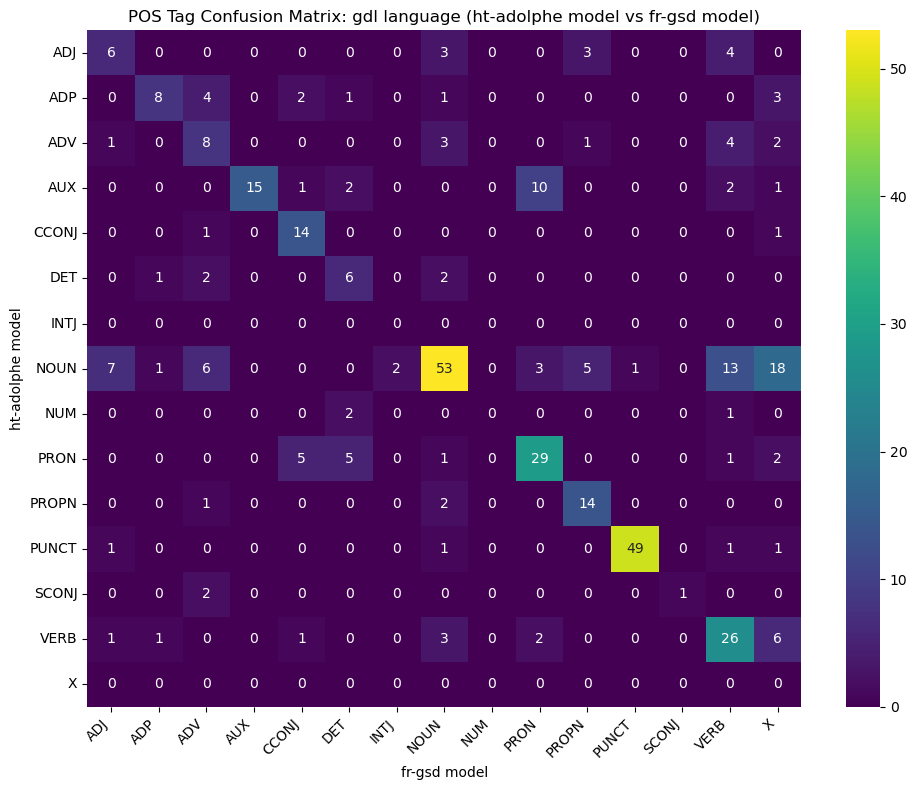

In [87]:
import seaborn as sns

def display_matrix(cm_df, label_x, label_y, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='viridis', ax=ax)
    
    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    ax.set_title(title)
    
    # rotate x-axis tick labels obliquely
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

display_matrix(cm_df_gdl, 'fr-gsd model', 'ht-adolphe model', 'POS Tag Confusion Matrix: gdl language (ht-adolphe model vs fr-gsd model)')

In [102]:
print(c_report_gdl)

              precision    recall  f1-score   support

         ADJ       0.38      0.38      0.38        16
         ADP       0.73      0.42      0.53        19
         ADV       0.33      0.42      0.37        19
         AUX       1.00      0.48      0.65        31
       CCONJ       0.61      0.88      0.72        16
         DET       0.38      0.55      0.44        11
        INTJ       0.00      0.00      0.00         0
        NOUN       0.77      0.49      0.60       109
         NUM       0.00      0.00      0.00         3
        PRON       0.66      0.67      0.67        43
       PROPN       0.61      0.82      0.70        17
       PUNCT       0.98      0.92      0.95        53
       SCONJ       1.00      0.33      0.50         3
        VERB       0.50      0.65      0.57        40
           X       0.00      0.00      0.00         0

    accuracy                           0.60       380
   macro avg       0.53      0.47      0.47       380
weighted avg       0.71   

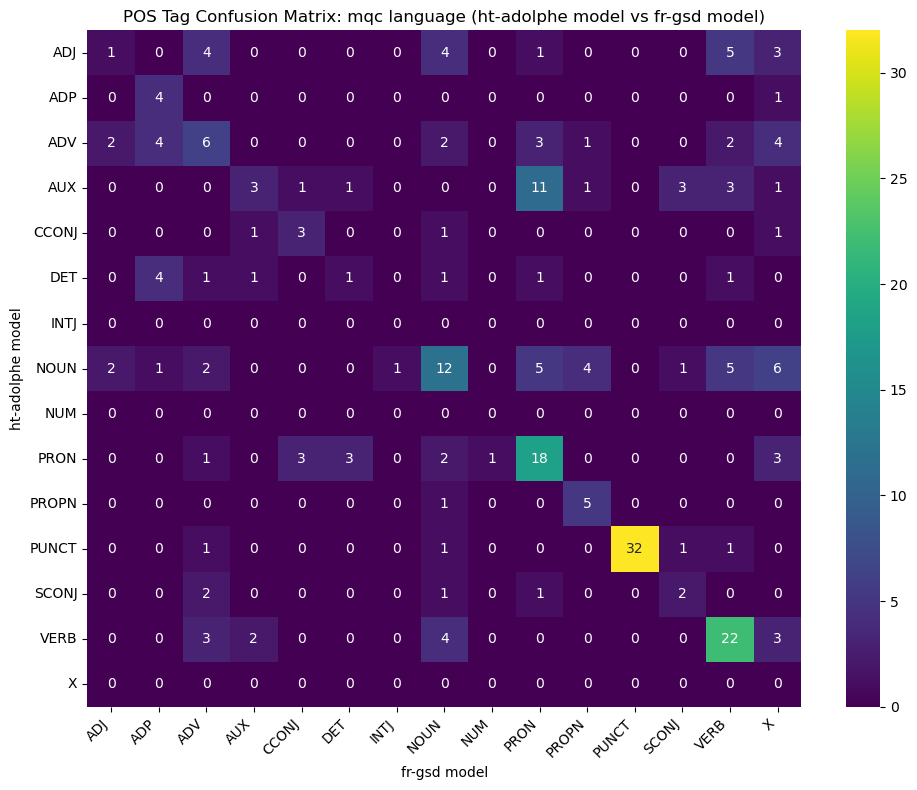

In [89]:
display_matrix(cm_df_mqc, 'fr-gsd model', 'ht-adolphe model', 'POS Tag Confusion Matrix: mqc language (ht-adolphe model vs fr-gsd model)')

In [104]:
print(c_report_mqc)

              precision    recall  f1-score   support

         ADJ       0.20      0.06      0.09        18
         ADP       0.31      0.80      0.44         5
         ADV       0.30      0.25      0.27        24
         AUX       0.43      0.12      0.19        24
       CCONJ       0.43      0.50      0.46         6
         DET       0.20      0.10      0.13        10
        INTJ       0.00      0.00      0.00         0
        NOUN       0.41      0.31      0.35        39
         NUM       0.00      0.00      0.00         0
        PRON       0.45      0.58      0.51        31
       PROPN       0.45      0.83      0.59         6
       PUNCT       1.00      0.89      0.94        36
       SCONJ       0.29      0.33      0.31         6
        VERB       0.56      0.65      0.60        34
           X       0.00      0.00      0.00         0

    accuracy                           0.46       239
   macro avg       0.34      0.36      0.33       239
weighted avg       0.49   

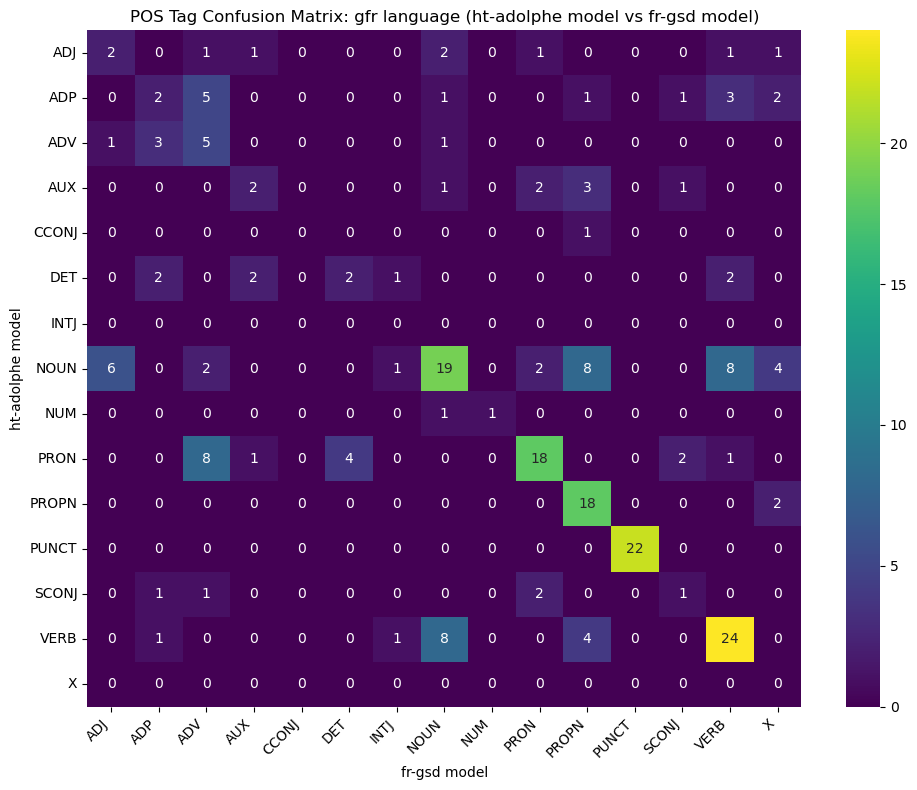

In [91]:
display_matrix(cm_df_gfr, 'fr-gsd model', 'ht-adolphe model', 'POS Tag Confusion Matrix: gfr language (ht-adolphe model vs fr-gsd model)')

In [106]:
print(c_report_gfr)

              precision    recall  f1-score   support

         ADJ       0.22      0.22      0.22         9
         ADP       0.22      0.13      0.17        15
         ADV       0.23      0.50      0.31        10
         AUX       0.33      0.22      0.27         9
       CCONJ       0.00      0.00      0.00         1
         DET       0.33      0.22      0.27         9
        INTJ       0.00      0.00      0.00         0
        NOUN       0.58      0.38      0.46        50
         NUM       1.00      0.50      0.67         2
        PRON       0.72      0.53      0.61        34
       PROPN       0.51      0.90      0.65        20
       PUNCT       1.00      1.00      1.00        22
       SCONJ       0.20      0.20      0.20         5
        VERB       0.62      0.63      0.62        38
           X       0.00      0.00      0.00         0

    accuracy                           0.52       224
   macro avg       0.40      0.36      0.36       224
weighted avg       0.56   

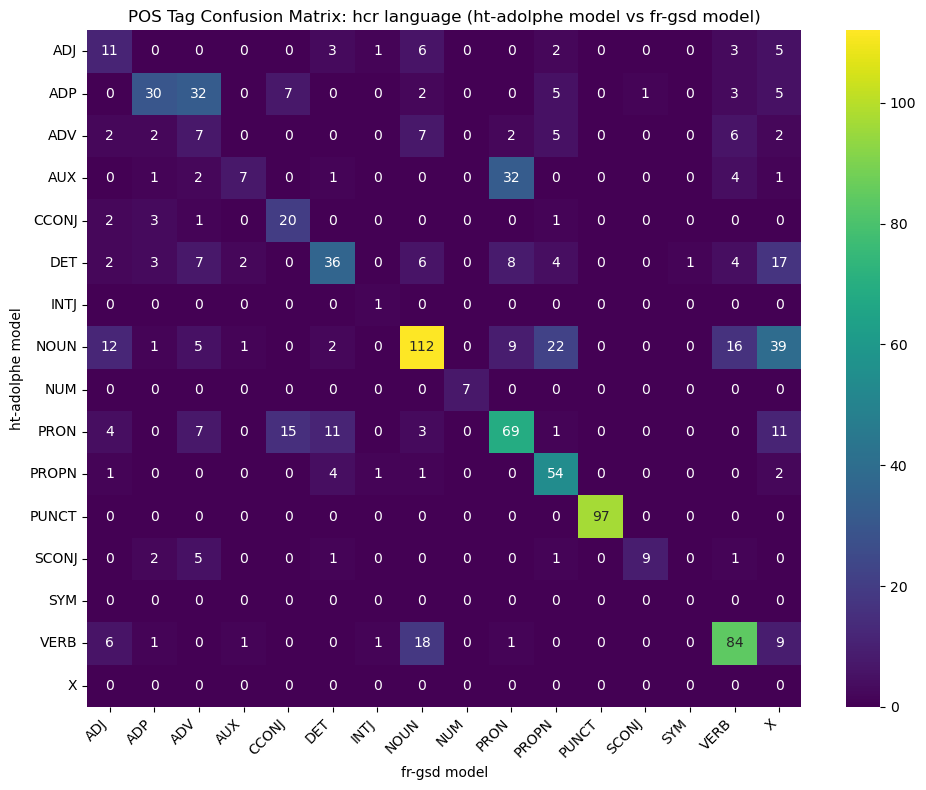

In [93]:
display_matrix(cm_df_hcr, 'fr-gsd model', 'ht-adolphe model', 'POS Tag Confusion Matrix: hcr language (ht-adolphe model vs fr-gsd model)')

In [108]:
print(c_report_hcr)

              precision    recall  f1-score   support

         ADJ       0.28      0.35      0.31        31
         ADP       0.70      0.35      0.47        85
         ADV       0.11      0.21      0.14        33
         AUX       0.64      0.15      0.24        48
       CCONJ       0.48      0.74      0.58        27
         DET       0.62      0.40      0.49        90
        INTJ       0.25      1.00      0.40         1
        NOUN       0.72      0.51      0.60       219
         NUM       1.00      1.00      1.00         7
        PRON       0.57      0.57      0.57       121
       PROPN       0.57      0.86      0.68        63
       PUNCT       1.00      1.00      1.00        97
       SCONJ       0.90      0.47      0.62        19
         SYM       0.00      0.00      0.00         0
        VERB       0.69      0.69      0.69       121
           X       0.00      0.00      0.00         0

    accuracy                           0.57       962
   macro avg       0.53   

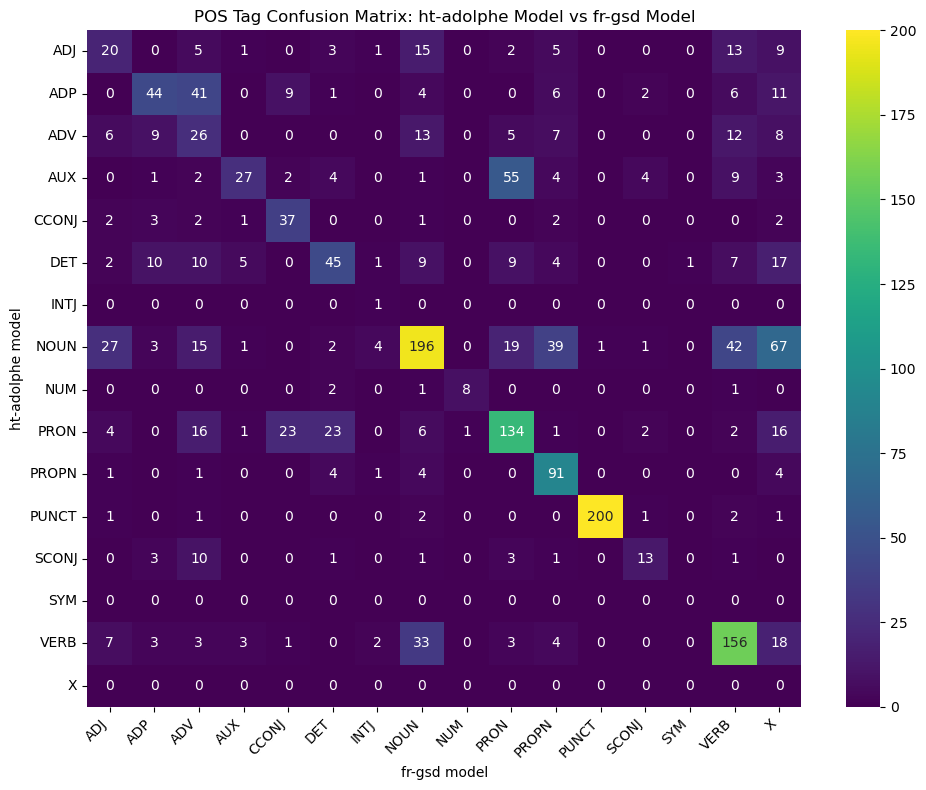

In [95]:
# peut-être un truc à faire pour passer des confusion matrix par langues à par modèles (à voir le type d'objet qu'est gdl_tags_fr)
aligned_tags_ht = aligned_gdl_tags_ht + aligned_mqc_tags_ht + aligned_gfr_tags_ht + aligned_hcr_tags_ht
aligned_tags_fr = aligned_gdl_tags_fr + aligned_mqc_tags_fr + aligned_gfr_tags_fr + aligned_hcr_tags_fr

cm_df_htfr, c_report_htfr = make_cm(aligned_tags_ht, aligned_tags_fr)

display_matrix(cm_df_htfr, 'fr-gsd model', 'ht-adolphe model', 'POS Tag Confusion Matrix: ht-adolphe Model vs fr-gsd Model')

In [100]:
print(c_report_htfr)

              precision    recall  f1-score   support

         ADJ       0.29      0.27      0.28        74
         ADP       0.58      0.35      0.44       124
         ADV       0.20      0.30      0.24        86
         AUX       0.69      0.24      0.36       112
       CCONJ       0.51      0.74      0.61        50
         DET       0.53      0.38      0.44       120
        INTJ       0.10      1.00      0.18         1
        NOUN       0.69      0.47      0.56       417
         NUM       0.89      0.67      0.76        12
        PRON       0.58      0.59      0.58       229
       PROPN       0.55      0.86      0.67       106
       PUNCT       1.00      0.96      0.98       208
       SCONJ       0.57      0.39      0.46        33
         SYM       0.00      0.00      0.00         0
        VERB       0.62      0.67      0.64       233
           X       0.00      0.00      0.00         0

    accuracy                           0.55      1805
   macro avg       0.49   

-> Considering all defaults of the fr-gsd model's tagging, choice made to perform the regex index search with the ht-adolphe tags.

(à ajouter dans les limites : Universal Dependencies treebanks in their classical, deep and surface-syntactic flavors can be queried. = nous c'est pas deep)

### 3. Get subsets for manual annotation in Arborator Grew

In [134]:
#pour choisir au hasard quelles phrases vont être annotées manuellement
import random

def get_subset(conllu_file, range_=50, seed=None, as_conllu_file=None):
    """Obtains a random subset of 50 sentences from a conllu file. 
    Either downloads the subset as a conllu file, or outputs the subset as a dictionary with the chosen sentences and their ID."""
    rng = random.Random(seed)
    sampled = rng.sample(list(conllu_file), range_)
    
    if as_conllu_file:
        with open(as_conllu_file, 'w', encoding='utf-8') as f:
            for sentence in sampled:
                f.write(sentence.conll() + '\n\n')
        return None

    return {s.id: s.text for s in sampled}

# as a file 
get_subset(gdl_ht_sent_f, range_=50, seed=42, as_conllu_file='subset_gdl.conllu')
get_subset(mqc_ht_sent_f, range_=50, seed=42, as_conllu_file='subset_mqc.conllu')
get_subset(gfr_ht_sent_f, range_=50, seed=42, as_conllu_file='subset_gfr.conllu')
get_subset(hcr_ht_sent_f, range_=50, seed=42, as_conllu_file='subset_hcr.conllu')

In [136]:
# as a dict
subset_gdl_dict = get_subset(gdl_ht_sent_f, range_=50, seed=42)
subset_mqc_dict = get_subset(mqc_ht_sent_f, range_=50, seed=42)
subset_gfr_dict = get_subset(gfr_ht_sent_f, range_=50, seed=42)
subset_hcr_dict = get_subset(hcr_ht_sent_f, range_=50, seed=42)

In [138]:
print(subset_gdl_dict)

{'233': "Alos, i présé yo, i chanté pli vit ; zié'y kléré ; jou té ka ouvè.", '53': 'On mòso a lajan sé òwganizasyon rédé-moun lasa ka sèvi èvè y la sé on lajan ki sòti dyèktéman an pòch a gouvèlman Etazini, on gouvèlman ki apiyé pou onpilo adan mannèv ki pòté viré anfendéfen an pòch mériken – pou on pa pi gwo pasé sa ki fèt pou dòt péyi gwo lizinaj.', '578': 'aswè ; jan yo ka détèrminé-y : chimen-la /', '515': "-An ké ba'w.", '471': 'Lè sak a yo plen, yo pati, yo viré.', '292': 'Mwen enki santi tout ti pangnol an té aprann lékol, ek tou sa sa an té glanné adwat-agoch, tou sa rantré annaks, é bel fraz pangnol té ka sòti an bouch an mwen kon dlo riviè, nawflaw.', '214': 'yon glan »', '1164': 'Konmen tan pou pasé asi yo ?', '182': 'I té ka chanté tou dousman : « Dédé konnan, dédé a lépé.', '1263': '(Men tansion !!', '896': 'Tout nonm déwò : jenn kon vyé, mi kon vèt, avòté kon matrité.', '67': 'Ja tini yonn – omwens – trannmandtè la pa kité anzèb.', '63': 'piplis ankò.', '196': 'tout sot 

In [140]:
print(len(subset_gdl_dict))

50


In [ ]:
# pour obtenir liste pos tags des subsets, réutiliser fonction get_tags sur les fichiers subsets!